# VoxelMorph with a progressive coarse-to-fine field

Extension of Balakrishnan et al. (IEEE TMI 2019) on neurite-OASIS.
Compares the baseline against a progressive variant that predicts one displacement field per
decoder level and warps each level's skip features by the field accumulated so far.

## 1. Preliminaries

In [1]:
import subprocess, sys
for pkg in ['nibabel', 'scipy', 'matplotlib', 'tqdm']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', '-q', 'install', pkg], check=True)

In [2]:
import hashlib, json, tarfile, time, urllib.request
from pathlib import Path

import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy import stats
from tqdm.auto import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# reuse an existing data/ if this notebook sits inside a checkout that already has one,
# otherwise create one here and download into it
DATA = next((c / 'data' for c in [Path.cwd(), *Path.cwd().parents]
             if (c / 'data' / 'oasis2d.npz').exists()), Path.cwd() / 'data')
DATA.mkdir(exist_ok=True)
torch.backends.cudnn.benchmark = True
print(torch.__version__, DEVICE, '| data:', DATA)

2.5.1+cu121 cuda | data: /data/home/ido.falah/VoxelMorphProject/data


/data/home/ido.falah/VoxelMorphProject/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Download neurite-OASIS. The 2D set is 24 MB; the 3D set is a 6.6 GB archive from which only the
template-space volumes are extracted. Both steps are skipped if the output already exists.

In [3]:
BASE = 'https://surfer.nmr.mgh.harvard.edu/ftp/data/neurite/data'
# the host rejects urllib's and curl's default user-agent
HEADERS = {'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 '
                         '(KHTML, like Gecko) Chrome/120 Safari/537.36'}

MD5 = {'neurite-oasis.2d.v1.0.tar': 'c9ae5864f250c7e4b8d83a104e51ae8e',
       'neurite-oasis.v1.0.tar': '081392a8150ff99ab7a64a9ded377835'}

def _md5(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while chunk := f.read(1 << 22):
            h.update(chunk)
    return h.hexdigest()

def download(name, attempts=5):
    # Download to a .part file and only rename once the checksum matches. Without this a
    # connection dropped mid-transfer leaves a truncated archive that every later run treats as
    # complete, and the failure surfaces much later as a tar read error.
    out = DATA / name
    if out.exists() and _md5(out) == MD5[name]:
        return out
    part = out.with_suffix(out.suffix + '.part')
    for attempt in range(1, attempts + 1):
        have = part.stat().st_size if part.exists() else 0
        req = urllib.request.Request(f'{BASE}/{name}', headers=dict(HEADERS))
        if have:
            req.add_header('Range', f'bytes={have}-')
        try:
            with urllib.request.urlopen(req) as r, open(part, 'ab' if have else 'wb') as f:
                while chunk := r.read(1 << 22):
                    f.write(chunk)
        except Exception as exc:
            print(f'  attempt {attempt}: {type(exc).__name__}, resuming')
            continue
        if _md5(part) == MD5[name]:
            part.rename(out)
            return out
        print(f'  attempt {attempt}: checksum mismatch, restarting')
        part.unlink(missing_ok=True)
    raise RuntimeError(f'could not download {name}')

RUN_3D = True   # 6.6 GB download and a 17 GB cache; set False for 2D only

In [4]:
if not (DATA / 'OASIS_OAS1_0001_MR1').exists():
    with tarfile.open(download('neurite-oasis.2d.v1.0.tar')) as t:
        t.extractall(DATA)

if RUN_3D and not (DATA / 'oasis3d').exists():
    keep = ('aligned_norm.nii.gz', 'aligned_seg35.nii.gz')
    with tarfile.open(download('neurite-oasis.v1.0.tar')) as t:
        members = [m for m in t.getmembers() if m.name.endswith(keep)]
        t.extractall(DATA / 'oasis3d', members=members)
print(f"2D subjects {len(list(DATA.glob('OASIS_OAS1_*')))}",
      f"| 3D subjects {len(list((DATA / 'oasis3d').glob('OASIS_OAS1_*'))) if RUN_3D else 0}")

2D subjects 414 | 3D subjects 414


Cache the volumes as arrays. 2D fits in memory; 3D is written to `.npy` and memory-mapped,
since the image stack alone is 11 GB.

In [5]:
FILES = {2: ('slice_norm.nii.gz', 'slice_seg24.nii.gz'),
         3: ('aligned_norm.nii.gz', 'aligned_seg35.nii.gz')}

def build_cache(ndim):
    root = DATA if ndim == 2 else DATA / 'oasis3d'
    out = DATA / ('oasis2d.npz' if ndim == 2 else 'oasis3d_cache')
    if out.exists():
        return out
    subjects = sorted(p.name for p in root.glob('OASIS_OAS1_*'))
    image_name, seg_name = FILES[ndim]
    images, segs = [], []
    for i, s in enumerate(subjects):
        img = np.asarray(nib.load(root / s / image_name).dataobj, dtype=np.float32).squeeze()
        seg = np.asarray(nib.load(root / s / seg_name).dataobj, dtype=np.uint8).squeeze()
        lo, hi = img.min(), img.max()
        images.append((img - lo) / (hi - lo) if hi > lo else img)
        segs.append(seg)
        if i % 100 == 0:
            print(f'  {i}/{len(subjects)}')
    images, segs = np.stack(images), np.stack(segs)
    if ndim == 2:
        np.savez_compressed(out, images=images, segs=segs, subjects=subjects)
    else:
        out.mkdir()
        np.save(out / 'images.npy', images); np.save(out / 'segs.npy', segs)
        (out / 'subjects.json').write_text(json.dumps(subjects))
    return out

build_cache(2)
if RUN_3D:
    build_cache(3)
print('cached')

cached


In [6]:
class Dataset:
    """Volumes plus the seeded splits. 3D is memory-mapped; 2D is held on the device."""

    def __init__(self, ndim):
        self.ndim = ndim
        if ndim == 2:
            with np.load(DATA / 'oasis2d.npz', allow_pickle=True) as z:
                self.images = torch.from_numpy(z['images']).to(DEVICE)
                self.segs = torch.from_numpy(z['segs'].astype(np.int16)).to(DEVICE)
        else:
            self.images = np.load(DATA / 'oasis3d_cache/images.npy', mmap_mode='r')
            self.segs = np.load(DATA / 'oasis3d_cache/segs.npy', mmap_mode='r')
        self.shape = tuple(self.images[0].shape)
        self.splits = make_splits(len(self.images))

    def batch(self, idx):
        x = self.images[list(idx)]
        x = x if torch.is_tensor(x) else torch.from_numpy(np.asarray(x))
        return x.unsqueeze(1).float().to(DEVICE)

    def seg(self, i):
        s = self.segs[i]
        return np.asarray(s.cpu() if torch.is_tensor(s) else s)

def make_splits(n, n_train=100, n_val=50, n_test=100, seed=0):
    perm = np.random.default_rng(seed).permutation(n)
    return {'train': perm[:n_train].tolist(),
            'val': perm[n_train:n_train + n_val].tolist(),
            'test': perm[n_train + n_val:n_train + n_val + n_test].tolist()}

def fixed_pairs(indices, n_pairs=100, seed=1234):
    """Deterministic (fixed, moving) list. Every model is scored on this same list."""
    rng = np.random.default_rng(seed)
    indices, pairs, seen = np.asarray(indices), [], set()
    while len(pairs) < n_pairs:
        f, m = rng.choice(indices, size=2, replace=False)
        if (int(f), int(m)) in seen:
            continue
        seen.add((int(f), int(m))); pairs.append((int(f), int(m)))
    return pairs

def evaluation_labels(data, indices, min_size=100, policy='median'):
    """Structures large enough to score reliably. One bincount pass per subject."""
    rows = [np.bincount(np.asarray(data.seg(i)).ravel()) for i in indices]
    width = max(len(r) for r in rows)
    table = np.zeros((len(rows), width), dtype=np.int64)
    for r, counts in enumerate(rows):
        table[r, :len(counts)] = counts
    keep = []
    for label in range(1, width):
        column = table[:, label]
        if not column.any():
            continue
        size = column.min() if policy == 'strict' else np.median(column)
        if size >= min_size:
            keep.append(label)
    return keep

In [7]:
d2 = Dataset(2)
PAIRS_2D = fixed_pairs(d2.splits['test'])
LABELS_2D = evaluation_labels(d2, d2.splits['test'], policy='median')
print(f"2D  shape {d2.shape}  train/val/test "
      f"{len(d2.splits['train'])}/{len(d2.splits['val'])}/{len(d2.splits['test'])}"
      f"  pairs {len(PAIRS_2D)}  structures {len(LABELS_2D)}")

if RUN_3D:
    d3 = Dataset(3)
    PAIRS_3D = fixed_pairs(d3.splits['test'])
    LABELS_3D = evaluation_labels(d3, d3.splits['test'], policy='strict')
    print(f"3D  shape {d3.shape}  pairs {len(PAIRS_3D)}  structures {len(LABELS_3D)}")

2D  shape (160, 192)  train/val/test 100/50/100  pairs 100  structures 14
3D  shape (160, 192, 224)  pairs 100  structures 31


## 2. Model building

Both models share the same UNet and differ only in how the displacement field is produced.

Warping and integration. A displacement is in voxels, so `grid_sample` coordinates are the
voxel grid plus the field, rescaled to `[-1, 1]`. With `integration_steps > 0` the network's
output is treated as a stationary velocity field and integrated by scaling and squaring, which
keeps the transform diffeomorphic.

In [8]:
_GRID_CACHE = {}

def _voxel_grid(shape, device, dtype):
    # scaling-and-squaring warps 7 times per forward pass; rebuilding a 3 x 160 x 192 x 224
    # grid each time dominates the 3D step, so it is built once per shape
    key = (tuple(shape), str(device), dtype)
    if key not in _GRID_CACHE:
        _GRID_CACHE[key] = torch.stack(torch.meshgrid(
            [torch.arange(s, device=device, dtype=dtype) for s in shape], indexing='ij'))
    return _GRID_CACHE[key]

def spatial_transform(image, disp, mode='bilinear'):
    """T(x) = image(x + u(x)); disp is in voxels, shape (B, ndim, *spatial)."""
    shape = disp.shape[2:]
    coords = _voxel_grid(shape, disp.device, disp.dtype).unsqueeze(0) + disp
    norm = [2.0 * coords[:, i] / max(shape[i] - 1, 1) - 1.0 for i in range(len(shape))]
    grid_coords = torch.stack(norm, dim=-1).flip(-1)   # grid_sample wants x fastest
    if not torch.is_floating_point(image):
        return F.grid_sample(image.float(), grid_coords, mode='nearest',
                             align_corners=True).to(image.dtype)
    return F.grid_sample(image, grid_coords, mode=mode, align_corners=True)

def integrate_velocity(velocity, steps):
    disp = velocity / (2 ** steps)
    for _ in range(steps):
        disp = disp + spatial_transform(disp, disp)
    return disp

The UNet: five encoder levels (conv, ReLU, max-pool) and five decoder levels
(upsample, concatenate skip, conv, ReLU).

In [9]:
def _conv(ndim, cin, cout, k=3):
    return (nn.Conv2d if ndim == 2 else nn.Conv3d)(cin, cout, kernel_size=k, padding=k // 2)

class UNet(nn.Module):
    def __init__(self, ndim, in_channels, nb_features=(16, 32, 32, 32, 32)):
        super().__init__()
        self.ndim = ndim
        self.pool = (nn.MaxPool2d if ndim == 2 else nn.MaxPool3d)(2, 2)
        self.up_mode = 'bilinear' if ndim == 2 else 'trilinear'

        down = list(nb_features)
        self.down_convs = nn.ModuleList()
        prev = in_channels
        for width in down:
            self.down_convs.append(_conv(ndim, prev, width)); prev = width
        self.bottleneck = _conv(ndim, down[-1], down[-1])

        up, skips = list(reversed(down)), list(reversed(down))
        self.up_convs, self.up_channels = nn.ModuleList(), []
        prev = down[-1]
        for i in range(len(up)):
            out = up[i + 1] if i + 1 < len(up) else up[-1]
            self.up_convs.append(_conv(ndim, prev + skips[i], out))
            self.up_channels.append(out); prev = out

    def encode(self, x):
        skips = []
        for conv in self.down_convs:
            x = F.relu(conv(x)); skips.append(x); x = self.pool(x)
        return F.relu(self.bottleneck(x)), skips

    def upsample(self, x, size):
        # to the skip's size rather than scale_factor=2, so odd shapes still line up
        return F.interpolate(x, size=size, mode=self.up_mode, align_corners=False)

### 2.i Base model

The decoder runs to full resolution and a single output path converts its features to a field:
a 1x1 convolution to `ndim` channels, then a 3x3 convolution on the field.

In [10]:
class Baseline(nn.Module):
    def __init__(self, ndim, nb_features=(16, 32, 32, 32, 32), integration_steps=7):
        super().__init__()
        self.ndim, self.integration_steps = ndim, integration_steps
        self.unet = UNet(ndim, 2, nb_features)
        self.out_layer = _conv(ndim, self.unet.up_channels[-1], ndim, k=1)
        self.flow_layer = _conv(ndim, ndim, ndim, k=3)
        # near-zero init so the model starts at the identity transform
        nn.init.normal_(self.flow_layer.weight, 0.0, 1e-5)
        nn.init.zeros_(self.flow_layer.bias)

    def forward(self, source, target):
        x, skips = self.unet.encode(torch.cat([source, target], 1))
        for conv, skip in zip(self.unet.up_convs, reversed(skips)):
            x = self.unet.upsample(x, skip.shape[2:])
            x = F.relu(conv(torch.cat([x, skip], 1)))
        velocity = self.flow_layer(self.out_layer(x))
        disp = integrate_velocity(velocity, self.integration_steps) \
            if self.integration_steps > 0 else velocity
        return {'displacement': disp, 'warped_source': spatial_transform(source, disp)}

### 2.ii Progressive model

Same UNet. Each decoder level emits its own field; the running field is upsampled and the
level's residual is added. Before a level runs, its skip features are warped by the field so
far, so each level only explains the residual left by the coarser ones.

`progressive=False` keeps the per-level heads but removes the warping — the control that
separates the two changes.

In [11]:
class Progressive(nn.Module):
    def __init__(self, ndim, nb_features=(16, 32, 32, 32, 32), integration_steps=7,
                 progressive=True):
        super().__init__()
        self.ndim, self.integration_steps = ndim, integration_steps
        self.progressive = progressive
        self.unet = UNet(ndim, 2, nb_features)
        self.flow_heads = nn.ModuleList(
            [_conv(ndim, c, ndim, k=3) for c in self.unet.up_channels])
        for head in self.flow_heads:
            nn.init.normal_(head.weight, 0.0, 1e-5); nn.init.zeros_(head.bias)

    def _upsample_field(self, field, shape):
        mode = 'bilinear' if self.ndim == 2 else 'trilinear'
        out = F.interpolate(field, size=tuple(shape), mode=mode, align_corners=True)
        for axis, (new, old) in enumerate(zip(shape, field.shape[2:])):
            out[:, axis] = out[:, axis] * (new / old)   # a field is measured in voxels
        return out

    def forward(self, source, target):
        x, skips = self.unet.encode(torch.cat([source, target], 1))
        field = None
        for head, conv, skip in zip(self.flow_heads, self.unet.up_convs, reversed(skips)):
            if field is not None:
                field = self._upsample_field(field, skip.shape[2:])
                if self.progressive:
                    skip = spatial_transform(skip, field)     # <- the mechanism
            x = self.unet.upsample(x, skip.shape[2:])
            x = F.relu(conv(torch.cat([x, skip], 1)))
            residual = head(x)
            field = residual if field is None else field + residual
        disp = integrate_velocity(field, self.integration_steps) \
            if self.integration_steps > 0 else field
        return {'displacement': disp, 'warped_source': spatial_transform(source, disp)}

In [12]:
def head_body(model):
    keys = ('out_layer', 'flow_layer', 'flow_heads')
    head = sum(p.numel() for n, p in model.named_parameters() if any(k in n for k in keys))
    return head, sum(p.numel() for p in model.parameters()) - head

print(f"{'model':<24}{'body':>10}{'head':>10}{'total':>10}")
for ndim in ([2, 3] if RUN_3D else [2]):
    for name, model in [(f'{ndim}D baseline', Baseline(ndim)),
                        (f'{ndim}D progressive', Progressive(ndim))]:
        h, b = head_body(model)
        print(f'{name:<24}{b:>10,}{h:>10,}{h + b:>10,}')

model                         body      head     total
2D baseline                111,184        72   111,256
2D progressive             111,184     2,314   113,498
3D baseline                332,944       297   333,241
3D progressive             332,944    10,383   343,327


In [13]:
# resolution at each decoder level, and how many voxels each flow head covers
model = Progressive(2)
x, skips = model.unet.encode(torch.zeros(1, 2, *d2.shape))
for i, skip in enumerate(reversed(skips)):
    print(f'  level {i}  {tuple(skip.shape[2:])}  {d2.shape[0] // skip.shape[2]}x downsampled')

  level 0  (10, 12)  16x downsampled
  level 1  (20, 24)  8x downsampled
  level 2  (40, 48)  4x downsampled
  level 3  (80, 96)  2x downsampled
  level 4  (160, 192)  1x downsampled


## 3. Running the models

Objective: `MSE(fixed, warped_moving) + lambda * grad_smoothness(displacement)`, identical for
both models and applied once, to the final field.

In [14]:
def registration_loss(target, warped_source, disp, lambda_reg):
    similarity = (target - warped_source).pow(2).mean()
    smooth = disp.new_zeros(())
    for axis in range(disp.dim() - 2):
        smooth = smooth + torch.diff(disp, dim=2 + axis).pow(2).mean(dim=1, keepdim=True).mean()
    smooth = smooth / (disp.dim() - 2)
    return {'total': similarity + lambda_reg * smooth,
            'similarity': similarity, 'smoothness': smooth}

class PairSampler:
    def __init__(self, data, split, batch_size, seed=0):
        self.data, self.batch_size = data, batch_size
        self.indices = np.asarray(data.splits[split])
        self.rng = np.random.default_rng(seed)

    def __next__(self):
        src = self.rng.choice(self.indices, size=self.batch_size)
        tgt = self.rng.choice(self.indices, size=self.batch_size)
        clash = src == tgt
        while clash.any():                    # registering a subject to itself carries no signal
            tgt[clash] = self.rng.choice(self.indices, size=int(clash.sum()))
            clash = src == tgt
        return self.data.batch(src), self.data.batch(tgt)

In [15]:
CKPT = Path('checkpoints'); CKPT.mkdir(exist_ok=True)

def train(model, data, steps, lambda_reg, batch_size, seed=0, lr=1e-4, tag=None):
    # Cached to checkpoints/ so re-running the notebook resumes instead of retraining.
    # Delete that directory to force a fresh run.
    model = model.to(DEVICE)
    ckpt = CKPT / f'{tag}.pt' if tag else None
    if ckpt is not None and ckpt.exists():
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        print(f'  {tag}: loaded cached checkpoint')
        return model

    torch.manual_seed(seed); np.random.seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sampler = PairSampler(data, 'train', batch_size, seed=seed)
    bar = tqdm(range(1, steps + 1), desc=tag or 'train', unit='step', leave=True)
    running = None
    for step in bar:
        source, target = next(sampler)
        opt.zero_grad(set_to_none=True)
        out = model(source, target)
        loss = registration_loss(target, out['warped_source'], out['displacement'], lambda_reg)
        loss['total'].backward(); opt.step()
        value = loss['total'].item()
        running = value if running is None else 0.98 * running + 0.02 * value
        if step % 50 == 0:
            bar.set_postfix(loss=f'{running:.5f}')
    if ckpt is not None:
        torch.save(model.state_dict(), ckpt)
    return model

In [16]:
def jacobian_determinant(disp):
    ndim, grads = disp.shape[1], []
    for axis in range(ndim):
        dim, extent = 2 + axis, disp.shape[2 + axis]
        d = (disp.narrow(dim, 2, extent - 2) - disp.narrow(dim, 0, extent - 2)) / 2.0
        for other in range(ndim):
            if other != axis:
                d = d.narrow(2 + other, 1, d.shape[2 + other] - 2)
        grads.append(d)
    e = lambda i, j: grads[j][:, i] + 1.0 if i == j else grads[j][:, i]
    if ndim == 2:
        return e(0, 0) * e(1, 1) - e(0, 1) * e(1, 0)
    return (e(0, 0) * (e(1, 1) * e(2, 2) - e(1, 2) * e(2, 1))
            - e(0, 1) * (e(1, 0) * e(2, 2) - e(1, 2) * e(2, 0))
            + e(0, 2) * (e(1, 0) * e(2, 1) - e(1, 1) * e(2, 0)))

def dice_per_structure(seg_fixed, seg_moved, labels):
    out = {}
    for label in labels:
        a, b = seg_fixed == label, seg_moved == label
        if not (a.any() or b.any()):
            out[label] = None                      # absent from both: dropped, not scored 0
        else:
            out[label] = float(2.0 * (a & b).sum() / (a.sum() + b.sum()))
    return out

def mean_dice(scores):
    vals = [v for v in scores.values() if v is not None]
    return float(np.mean(vals)) if vals else float('nan')

@torch.no_grad()
def evaluate(model, data, pairs, labels):
    model.eval()
    dice, fold, initial = [], [], []
    for fixed_idx, moving_idx in pairs:
        source, target = data.batch([moving_idx]), data.batch([fixed_idx])
        disp = model(source, target)['displacement']
        moving_seg = torch.from_numpy(data.seg(moving_idx)).to(DEVICE)[None, None].float()
        warped = spatial_transform(moving_seg, disp, mode='nearest').squeeze().cpu().numpy()
        fixed_seg, moving_np = data.seg(fixed_idx), data.seg(moving_idx)
        dice.append(mean_dice(dice_per_structure(fixed_seg, np.rint(warped), labels)))
        initial.append(mean_dice(dice_per_structure(fixed_seg, moving_np, labels)))
        det = jacobian_determinant(disp)
        fold.append(float((det <= 0).sum()) / det.numel())
    model.train()
    return np.array(dice), np.array(fold), np.array(initial)

2D: both models at three seeds each. The run — not the pair — is the unit of replication, so
three runs per arm is the minimum that supports a comparison.

In [17]:
STEPS_2D, LAMBDA_2D, BATCH_2D, SEEDS = 20000, 0.25, 16, (0, 1, 2)

models_2d = {'baseline': [], 'progressive': []}
for seed in SEEDS:
    for name, ctor in [('baseline', lambda: Baseline(2)), ('progressive', lambda: Progressive(2))]:
        models_2d[name].append(train(ctor(), d2, STEPS_2D, LAMBDA_2D, BATCH_2D,
                                     seed=seed, tag=f'2d_{name}_seed{seed}'))

  2d_baseline_seed0: loaded cached checkpoint


/tmp/ipykernel_1752634/2295647725.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
2d_progressive_seed2: 100%

In [18]:
scores_2d = {name: [evaluate(m, d2, PAIRS_2D, LABELS_2D) for m in models]
             for name, models in models_2d.items()}

print(f"2D, lambda={LAMBDA_2D}, {STEPS_2D} steps, {len(SEEDS)} seeds")
print(f"  unregistered {scores_2d['baseline'][0][2].mean():.4f}\n")
runs = {}
for name, results in scores_2d.items():
    runs[name] = np.array([d.mean() for d, _, _ in results])
    fold = np.mean([f.mean() for _, f, _ in results])
    print(f"  {name:<12} {runs[name].mean():.4f} +- {runs[name].std(ddof=1):.4f}"
          f"   runs {np.round(sorted(runs[name]), 4)}   folding {100 * fold:.3f}%")

2D, lambda=0.25, 20000 steps, 3 seeds
  unregistered 0.6747

  baseline     0.7517 +- 0.0041   runs [0.747  0.7535 0.7546]   folding 0.000%
  progressive  0.7547 +- 0.0014   runs [0.753  0.7554 0.7557]   folding 0.000%


Compared at the level of runs, not pairs. A paired per-pair test between two single runs is not
calibrated to run-to-run variation and will report significance for two runs of the *same*
configuration.

In [19]:
b, p = runs['baseline'], runs['progressive']
mean_p = stats.ttest_ind(p, b, equal_var=False).pvalue
var_ratio = np.var(b, ddof=1) / np.var(p, ddof=1)
df = len(b) - 1
var_p = 2 * min(stats.f.cdf(var_ratio, df, df), 1 - stats.f.cdf(var_ratio, df, df))
print(f"  difference of means {p.mean() - b.mean():+.4f}   Welch p = {mean_p:.3f}")
print(f"  variance ratio      {var_ratio:.1f}x           F-test p = {var_p:.4f}")

  difference of means +0.0030   Welch p = 0.336
  variance ratio      8.1x           F-test p = 0.2193


3D: one seed per arm, capped at 10k steps as a demonstration. The reported 3D results were
trained for 80k.

In [20]:
STEPS_3D, LAMBDA_3D, BATCH_3D = 10000, 0.05, 1

models_3d = {}
if RUN_3D:
    for name, ctor in [('baseline', lambda: Baseline(3)), ('progressive', lambda: Progressive(3))]:
        models_3d[name] = train(ctor(), d3, STEPS_3D, LAMBDA_3D, BATCH_3D, seed=0,
                                tag=f'3d_{name}_{STEPS_3D}')

3d_progressive_10000: 100%|██████████| 10000/10000 [34:05<00:00,  4.89step/s, loss=0.00209]


## 4. Results

Dice is averaged over structures present in the pair. Folding is the fraction of voxels with
non-positive Jacobian determinant of the transform `x + u(x)`.

In [21]:
if RUN_3D:
    print(f"3D, lambda={LAMBDA_3D}, {STEPS_3D} steps, 1 seed (demonstration)")
    d3_scores = {n: evaluate(m, d3, PAIRS_3D, LABELS_3D) for n, m in models_3d.items()}
    base = d3_scores['baseline'][0].mean()
    print(f"  unregistered {d3_scores['baseline'][2].mean():.4f}")
    for name, (dice, fold, _) in d3_scores.items():
        delta = '' if name == 'baseline' else f'   d {dice.mean() - base:+.4f}'
        print(f"  {name:<12} {dice.mean():.4f}   folding {100 * fold.mean():.3f}%{delta}")

/tmp/ipykernel_1752634/1728012947.py:38: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  moving_seg = torch.from_numpy(data.seg(moving_idx)).to(DEVICE)[None, None].float()


3D, lambda=0.05, 10000 steps, 1 seed (demonstration)
  unregistered 0.6295
  baseline     0.7832   folding 0.000%
  progressive  0.7943   folding 0.000%   d +0.0111


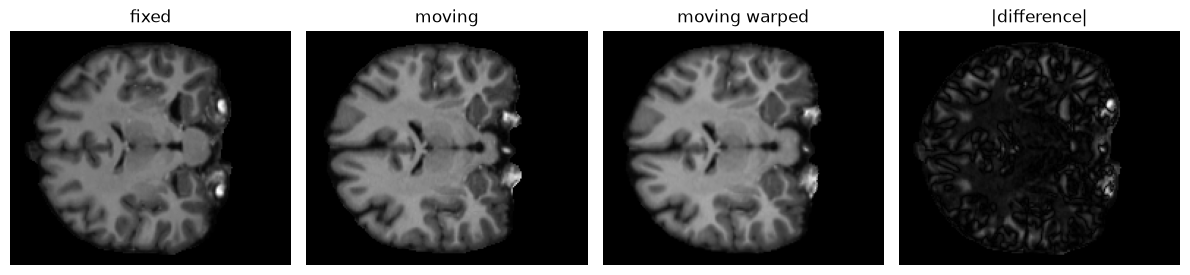

In [22]:
fixed_idx, moving_idx = PAIRS_2D[0]
source, target = d2.batch([moving_idx]), d2.batch([fixed_idx])
with torch.no_grad():
    out = models_2d['progressive'][0].eval()(source, target)

panels = [(target, 'fixed'), (source, 'moving'), (out['warped_source'], 'moving warped'),
          ((target - out['warped_source']).abs(), '|difference|')]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, (img, title) in zip(axes, panels):
    ax.imshow(img.squeeze().cpu().numpy(), cmap='gray'); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

### Reference: full-budget results

Trained separately at 60k steps (2D, 4 seeds) and 80k steps (3D, 1 seed). `heads only` is the
progressive model with the skip warping removed, keeping the per-level flow heads.

In [23]:
REFERENCE_2D = {'baseline': (0.7566, 0.003333), 'progressive': (0.7597, 0.000348)}
REFERENCE_2D_TESTS = {'mean_p': 0.161, 'var_ratio': 91.8, 'var_p': 0.0038}
REFERENCE_3D = {0.025: {'baseline': 0.8066, 'progressive': 0.8128, 'heads only': 0.8072},
                0.05:  {'baseline': 0.8054, 'progressive': 0.8144, 'heads only': 0.8090}}

mb, sb = REFERENCE_2D['baseline']; mp, sp = REFERENCE_2D['progressive']
print('2D, lambda=0.25, 60k steps, 4 seeds')
print(f'  baseline     {mb:.4f} +- {sb:.4f}')
print(f'  progressive  {mp:.4f} +- {sp:.4f}   d {mp - mb:+.4f}'
      f"  (mean p = {REFERENCE_2D_TESTS['mean_p']})")
print(f"  variance ratio {REFERENCE_2D_TESTS['var_ratio']:.0f}x"
      f"   (F-test p = {REFERENCE_2D_TESTS['var_p']})")
print('\n3D, 80k steps, 1 seed, 0.000% folding throughout')
for lam, arms in REFERENCE_3D.items():
    print(f'  lambda={lam}')
    for name, dice in arms.items():
        tag = '' if name == 'baseline' else f"   d {dice - arms['baseline']:+.4f}"
        print(f'    {name:<12} {dice:.4f}{tag}')

2D, lambda=0.25, 60k steps, 4 seeds
  baseline     0.7566 +- 0.0033
  progressive  0.7597 +- 0.0003   d +0.0031  (mean p = 0.161)
  variance ratio 92x   (F-test p = 0.0038)

3D, 80k steps, 1 seed, 0.000% folding throughout
  lambda=0.025
    baseline     0.8066
    progressive  0.8128   d +0.0062
    heads only   0.8072   d +0.0006
  lambda=0.05
    baseline     0.8054
    progressive  0.8144   d +0.0090
    heads only   0.8090   d +0.0036


## 5. Conclusions

- The two models differ only in the output path: a flow head per decoder level, and skip
  features warped by the accumulated field. Encoder, decoder, loss and lambda are identical.
- 2D at full budget: +0.0031 Dice, not significant across runs (p = 0.161).
- 2D run-to-run variance drops 92x (F-test p = 0.0038). The gain is mostly the removal of a
  bad-seed tail rather than a lift of the good runs.
- 3D at full budget: +0.0090 at lambda=0.05 and +0.0062 at lambda=0.025, no folding.
- Removing the skip warping and keeping the per-level heads gives +0.0036 and +0.0006, so the
  warping carries the effect.
- The 3D gain exceeds the 2D gain. 3D at 80k steps has seen fewer training pairs than 2D at
  20k, so the two are measured at different points on the convergence curve.

Open: the 3D results are single-seed, so run-to-run variance there is unmeasured.